datasetLink: https://www.kaggle.com/datasets/saurabhshahane/bengali-sentiment-classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data

In [3]:
#unzip the data
!unzip /content/dataset.zip

Archive:  /content/dataset.zip
  inflating: README.txt              
  inflating: all_negative_3307.txt   
  inflating: all_positive_8500.txt   


In [38]:
with open("/content/all_negative_3307.txt",'r',encoding='utf-8') as f:
  neg_texts = f.readlines()

In [39]:
with open("/content/all_positive_8500.txt",'r',encoding='utf-8') as f:
  pos_texts = f.readlines()

In [40]:
neg_texts = [text.strip() for text in neg_texts]
pos_texts = [text.strip() for text in pos_texts]

In [41]:
texts=neg_texts+pos_texts

In [42]:
len(neg_texts),len(pos_texts)

(3307, 8500)

In [43]:
neg_labels = [0]*len(neg_texts)
pos_labels = [1]*len(pos_texts)

In [44]:
len(neg_labels),len(pos_labels)

(3307, 8500)

In [45]:
labels=neg_labels+pos_labels

In [46]:
df=pd.DataFrame(
    {
        'text':texts,
        'label':labels
    }
)
df.head()

,text,label
0,আমার জীবনের সবথেকে ফালতু একটা নাটক এইটা,0
1,সাধারণ মানুষ টিভি চ্যানেল গুলো ছুড়ে ফেলে দিয়ে...,0
2,স্টুডেন্ট ওরে একটা থাপ্পড় মারো,0
3,নাটকটিতে কথা থেকে মিউজিকের সাউন্ডটা বেশি হয়ে গ...,0
4,পাকনা মেয়াটা একটা বাজে,0


In [47]:
df.tail()

,text,label
11802,নাটকটার এড দেখে বুঝতে পারছি অনেক ভালো লাগবে,1
11803,তিশাকে চশমায় সেই লাগে,1
11804,বাংলা নাটক মানেই মনের মধ্যে একটা অন্যরকম অনুভূ...,1
11805,"দেখা শুরু করলাম,, ভাল না হয়ে যাবে কই অপূর্ব বল...",1
11806,শুধু এই নাটকের জন্য চ্যানেলটি সাবস্ক্রাইব করলাম,1


In [48]:
df=df.sample(frac=1,random_state=42).reset_index(drop=True)

In [49]:
df.head(10)

,text,label
0,অসাধারণ লাগলো,1
1,জীবনে প্রথম তানজীন তিশার কোন ভাল নাটক দেখলাম,1
2,আজাইরা বিষয়বস্তু!!!,0
3,আমাদের দেশের নাটক গুলো ভালো। আর ও ভালো লাগবে ন...,1
4,খুব সুন্দর নাটক।,1
5,আহারে ঠিক অামার জামাই টার মতোঠিক নাটকের অভিনয় ...,1
6,"এই নাটক টা এখন পর্যন্ত চার বার দেখলাম,,,,,",1
7,শেষ টা হয় নাই,0
8,এক কথায় নাটক টা অসাধারণ হয়েছে,1
9,মনিরা মিঠুর অভিনয়টা বিরক্তিকর কন্ঠটা বেশি বিরক...,0


In [50]:
df['label'].value_counts()

,count
label,
1,8500
0,3307


# Data Cleaning

In [51]:
import re

def clean_text(text):

    # Convert to string
    text = str(text)

    # Remove English letters
    text = re.sub(r'[a-zA-Z]', ' ', text)

    # Remove numbers (English + Bangla)
    text = re.sub(r'[0-9০-৯]', ' ', text)

    # Keep only Bangla characters and spaces
    text = re.sub(r'[^\u0980-\u09FF\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text




In [52]:
text = "I ❤️ বাংলাদেশ!!! ২০২6 সালে AI শিখবো!!! 123"

cleaned = clean_text(text)

In [53]:
cleaned

'বাংলাদেশ সালে শিখবো'

# Remove Stop Words

In [54]:
bangla_stopwords = {
    "আমি", "আমাকে", "আমার", "আমরা", "আমাদের", "তুমি", "তোমাকে", "তোমার", "আপনি", "আপনার",
    "সে", "তাকে", "তার", "তারা", "তাদের", "তিনি", "তাঁকে", "তাঁর", "এবং", "ও", "আর", "কিন্তু",
    "অথবা", "অথচ", "নাকি", "কিংবা", "কারণ", "তাই", "তবে", "হয়", "হওয়া", "হয়েছে", "আছে", "ছিল",
    "না", "নেই", "নাই", "করা", "করার", "করে", "করেই", "জন্য", "থেকে", "পর্যন্ত", "মধ্যে", "এই",
    "এটি", "এটা", "ঐ", "ওই", "কোন", "কোনো", "কিছু", "খুব", "নিজে", "নিজের", "এর", "তে", "কে"
}


In [55]:
def remove_stopwords(text):
  words=text.split()

  filtered_words=[word
                  for word in words
                  if word not in bangla_stopwords]

  return ' '.join(filtered_words)

In [56]:
t = "I ❤️ বাংলাদেশ!!! ২০২6 সালে AI শিখবো!!! 123"
t.split()

['I', '❤️', 'বাংলাদেশ!!!', '২০২6', 'সালে', 'AI', 'শিখবো!!!', '123']

In [57]:
" ".join(['I', '❤️', 'বাংলাদেশ!!!', '২০২6', 'সালে', 'AI', 'শিখবো!!!', '123'])

'I ❤️ বাংলাদেশ!!! ২০২6 সালে AI শিখবো!!! 123'

In [58]:
df['text']=df['text'].apply(clean_text)
df['text']=df['text'].apply(remove_stopwords)

# Train Test Split

In [59]:
X=df['text']
y=df['label']

In [60]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(9445,)
(2362,)
(9445,)
(2362,)


# Model

In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [64]:
logistic_model=Pipeline(
    [
        ('tfid',TfidfVectorizer(ngram_range=(1,2),max_features=50000)),
        ('clf',LogisticRegression(max_iter=1000))
    ]
)

In [71]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Initialize the vectorizer
vectorizer = TfidfVectorizer(ngram_range=(1,2),max_features=4)

# 2. Provide sample documents
corpus = [
    "I love cat",
    "Cat is Good"
]

# 3. Fit and transform the text into a TF-IDF matrix
tfidf_matrix = vectorizer.fit_transform(corpus)

# 4. View the vocabulary and their corresponding index
print(vectorizer.vocabulary_)


{'cat': np.int64(0), 'is': np.int64(3), 'good': np.int64(2), 'cat is': np.int64(1)}


In [72]:
logistic_model.fit(X_train,y_train)

Pipeline(steps=[('tfid',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
                ('clf', LogisticRegression(max_iter=1000))])

In [73]:
y_pred=logistic_model.predict(X_test)

In [74]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [75]:
accuracy_score(y_test,y_pred)

0.8746824724809483

In [77]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.67      0.75       658
           1       0.88      0.95      0.92      1704

    accuracy                           0.87      2362
   macro avg       0.87      0.81      0.83      2362
weighted avg       0.87      0.87      0.87      2362



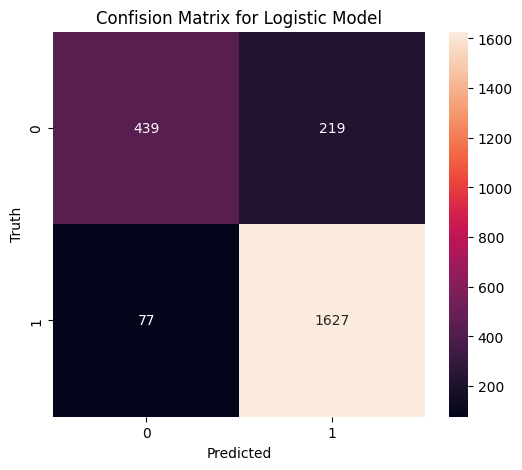

In [80]:
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title("Confision Matrix for Logistic Model")
plt.show()

In [81]:
# navie bayes
from sklearn.naive_bayes import MultinomialNB
nb_model=Pipeline(
    [
        ('tfid',TfidfVectorizer(ngram_range=(1,2),max_features=50000)),
        ('clf',MultinomialNB())
    ]
)

In [82]:
nb_model.fit(X_train,y_train)

Pipeline(steps=[('tfid',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
                ('clf', MultinomialNB())])

In [83]:
y_predn=nb_model.predict(X_test)

In [84]:
accuracy_score(y_test,y_predn)

0.8238780694326842

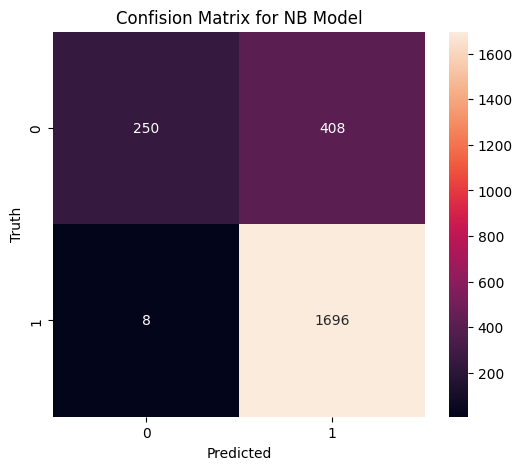

In [85]:
cm=confusion_matrix(y_test,y_predn)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title("Confision Matrix for NB Model")
plt.show()

#save model

In [86]:
# save the best model
import joblib
joblib.dump(logistic_model,'BanglasentimentModel.pkl')
print('Model Saved Successfully')

Model Saved Successfully


#Load saved Model

In [87]:
model=joblib.load('/content/BanglasentimentModel.pkl')

In [88]:
model

Pipeline(steps=[('tfid',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
                ('clf', LogisticRegression(max_iter=1000))])

In [98]:
text="পাকনা মেয়াটা একটা বাজে"
text=clean_text(text)
text=remove_stopwords(text)
prediction=model.predict([text])[0]
if prediction==1:
  print("Positive")
else:
  print("Negative")

Negative


In [92]:
model.predict([text])[0]

np.int64(0)

## Streamlit UI for Sentiment Analysis

To run the Streamlit application, you'll need to install Streamlit and create a Python file.

In [99]:
%%writefile app.py

import streamlit as st
import joblib
import re

# Load the model
model = joblib.load('BanglasentimentModel.pkl')

# Define clean_text function (from your notebook)
def clean_text(text):
    text = str(text)
    text = re.sub(r'[a-zA-Z]', ' ', text)
    text = re.sub(r'[0-9০-৯]', ' ', text)
    text = re.sub(r'[^ঀ-৿\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Define remove_stopwords function (from your notebook)
bangla_stopwords = {
    "আমি", "আমাকে", "আমার", "আমরা", "আমাদের", "তুমি", "তোমাকে", "তোমার", "আপনি", "আপনার",
    "সে", "তাকে", "তার", "তারা", "তাদের", "তিনি", "তাঁকে", "তাঁর", "এবং", "ও", "আর", "কিন্তু",
    "অথবা", "অথচ", "নাকি", "কিংবা", "কারণ", "তাই", "তবে", "হয়", "হওয়া", "হয়েছে", "আছে", "ছিল",
    "না", "নেই", "নাই", "করা", "করার", "করে", "করেই", "জন্য", "থেকে", "পর্যন্ত", "মধ্যে", "এই",
    "এটি", "এটা", "ঐ", "ওই", "কোন", "কোনো", "কিছু", "খুব", "নিজে", "নিজের", "এর", "তে", "কে"
}

def remove_stopwords(text):
  words = text.split()
  filtered_words = [word for word in words if word not in bangla_stopwords]
  return ' '.join(filtered_words)

# Streamlit UI
st.title('Bengali Sentiment Analysis')
st.write('Enter Bengali text below to predict its sentiment (Positive/Negative).')

user_input = st.text_area('Enter Text Here:')

if st.button('Predict Sentiment'):
    if user_input:
        cleaned_input = clean_text(user_input)
        processed_input = remove_stopwords(cleaned_input)

        if not processed_input.strip(): # Check if text is empty after cleaning and stopword removal
            st.warning("Please enter meaningful Bengali text. The input became empty after preprocessing.")
        else:
            prediction = model.predict([processed_input])[0]
            if prediction == 1:
                st.success('Sentiment: Positive')
            else:
                st.error('Sentiment: Negative')
    else:
        st.warning('Please enter some text to analyze.')


Writing app.py


Now, install `streamlit` and `pyngrok` (to expose the app publicly) and run the `app.py` file. Click the public URL to interact with your Streamlit app.

In [100]:
!pip install streamlit pyngrok -qq
from pyngrok import ngrok

# Terminate any previous ngrok tunnels
ngrok.kill()

# Start a new ngrok tunnel
public_url = ngrok.connect(8501)
print(f"Streamlit App URL: {public_url}")

# Run the Streamlit app in the background
!streamlit run app.py &>/dev/null&

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 37.7 MB/s eta 0:00:00


ERROR:pyngrok.process.ngrok:t=2026-06-28T17:37:59+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-06-28T17:37:59+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-06-28T17:37:59+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: This ngrok session is not authenticated

PyngrokNgrokError: The ngrok process errored on start: authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [ ]:
ngrok.set_auth_token("YOUR_AUTHTOKEN")